<a href="https://colab.research.google.com/github/endheo-oliveira/EngenhariaDePromptEAplicacaoAI/blob/main/Aula08AutomacaoIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

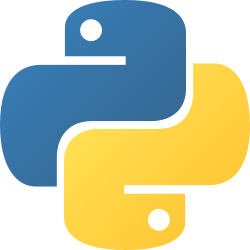

Aula 08 Automação com Inteligência

Nome: Endheo Rodrigues De Lima Oliveira

Desenvolver um script que define a temperatura


In [ ]:
# Define um valor de temperatura
temp_valor = int(input('Digite a temperatura atual: '))

# Verifica se a temperatura está acima do limite (30 graus)
if temp_valor > 30:
    # Se estiver, imprime um alerta de superaquecimento
    print('Alerta de superaquecimento!')
else:
    # Caso contrário, imprime que a temperatura está normal
    print('Temperatura normal.')

Desenvolver um script que consulte uma api publico (Viacep) e retorne as informacoes de endereço formatadas de maneira legivel.(Tratamento de exceções try/except)

In [ ]:
import requests # Importa a biblioteca requests para fazer requisições HTTP

def consultar_cep():
    while True: # Loop contínuo para permitir múltiplas consultas de CEP
        # Solicita ao usuário que digite o CEP ou 'sair' para encerrar
        cep = input("Digite o CEP (apenas números) ou 'sair' para encerrar: ")

        # Verifica se o usuário digitou 'sair' e encerra a consulta
        if cep.lower() == 'sair':
            print("Consulta encerrada.")
            break

        # Valida o formato do CEP: deve conter 8 dígitos numéricos
        if not cep.isdigit() or len(cep) != 8:
            print("CEP inválido. Por favor, digite 8 dígitos numéricos.")
            continue # Pula para a próxima iteração do loop

        # Constrói a URL da API ViaCEP com o CEP fornecido
        url = "https://viacep.com.br/ws/" + cep + "/json/"

        try:
            # Faz a requisição GET para a API ViaCEP com um tempo limite de 5 segundos
            response = requests.get(url, timeout=5)
            # Verifica se houve algum erro HTTP (código de status 4xx ou 5xx)
            response.raise_for_status()

            # Converte a resposta JSON em um dicionário Python
            data = response.json()

            # Verifica se a resposta JSON indica um erro (CEP não encontrado)
            if 'erro' in data and data['erro']:
                print("CEP '" + cep + "' não encontrado.")
            else:
                # Imprime as informações do endereço formatadas
                print("\n--- Informações do Endereço ---")
                print("CEP: " + data.get('cep', 'N/A')) # Usa .get() para evitar KeyError se a chave não existir
                print("Logradouro: " + data.get('logradouro', 'N/A'))
                print("Complemento: " + data.get('complemento', 'N/A'))
                print("Bairro: " + data.get('bairro', 'N/A'))
                print("Localidade: " + data.get('localidade', 'N/A'))
                print("UF: " + data.get('uf', 'N/A'))
                print("DDD: " + data.get('ddd', 'N/A'))
                print("-------------------------------\n")

        # Tratamento de exceções específicas para erros de requisição HTTP
        except requests.exceptions.HTTPError as http_err:
            print("Erro HTTP ao consultar CEP '" + cep + "': " + str(http_err))
        # Tratamento de exceções para erros de conexão (sem internet, por exemplo)
        except requests.exceptions.ConnectionError as conn_err:
            print("Erro de conexão ao consultar CEP '" + cep + "'. Verifique sua internet: " + str(conn_err))
        # Tratamento de exceções para requisições que excederam o tempo limite
        except requests.exceptions.Timeout as timeout_err:
            print("Tempo limite excedido ao consultar CEP '" + cep + "'. Tente novamente: " + str(timeout_err))
        # Tratamento de exceções gerais para outros erros de requisição
        except requests.exceptions.RequestException as req_err:
            print("Ocorreu um erro inesperado ao consultar CEP '" + cep + "': " + str(req_err))
        # Tratamento de exceções para erros na decodificação do JSON (resposta malformada)
        except ValueError:
            print("Erro ao decodificar a resposta JSON para o CEP '" + cep + "'.")
        # Tratamento de exceções para quaisquer outros erros inesperados
        except Exception as e:
            print("Um erro inesperado ocorreu: " + str(e))

# Chama a função para iniciar o processo de consulta do CEP
consultar_cep()


Criar um programa que organiza arquivos bagunçados em pastas automaticamente, baseando-se apenas  baseado-se apenas na extensão do arquivo(ex:.pdf, .jpg, .py, .doc)use a biblioteca os ou shutil.

In [ ]:
import os
import shutil
from pathlib import Path

def create_dummy_files(source_dir: str, dummy_files_config: dict):
    """Cria arquivos de exemplo para demonstração."""
    for filename, _ in dummy_files_config.items():
        file_path = Path(source_dir) / filename
        try:
            # Cria arquivos vazios de diferentes tipos
            file_path.touch()
        except Exception as e:
            print("Erro ao criar " + filename + ": " + str(e))

def organize_files(source_dir: str):
    """Organiza arquivos em pastas baseadas em suas extensões."""
    file_types = {
        'imagens': ['.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff'],
        'documentos': ['.pdf', '.doc', '.docx', '.txt', '.rtf', '.odt'],
        'planilhas': ['.xls', '.xlsx', '.csv', '.ods'],
        'apresentacoes': ['.ppt', '.pptx', '.odp'],
        'videos': ['.mp4', '.mkv', '.avi', '.mov', '.wmv', '.flv'],
        'audio': ['.mp3', '.wav', '.aac', '.flac', '.ogg'],
        'compactados': ['.zip', '.rar', '.7z', '.tar', '.gz'],
        'executaveis': ['.exe', '.msi', '.deb', '.rpm'],
        'codigos': ['.py', '.java', '.c', '.cpp', '.html', '.css', '.js'],
    }

    # Cria um dicionário reverso para facilitar a busca pela extensão
    extension_to_folder = {ext: folder for folder, extensions in file_types.items() for ext in extensions}

    source_path = Path(source_dir)

    print("Organizando arquivos em: " + str(source_path.resolve()) + " (Diretório atual)")

    # Itera sobre todos os itens no diretório de origem
    for item in source_path.iterdir():
        # Verifica se é um arquivo (e não um diretório)
        if item.is_file():
            # Obtém a extensão do arquivo e converte para minúsculas
            file_extension = item.suffix.lower()

            # Determina a pasta de destino
            # Se a extensão não estiver mapeada, move para 'outros'
            destination_folder_name = extension_to_folder.get(file_extension, 'outros')
            destination_dir = source_path / destination_folder_name

            # Cria a pasta de destino se ela não existir (exist_ok=True evita erro se já existir)
            destination_dir.mkdir(parents=True, exist_ok=True)

            # Constrói o caminho completo para o destino do arquivo
            destination_file_path = destination_dir / item.name

            try:
                # Move o arquivo para a pasta de destino
                shutil.move(item, destination_file_path)
                # Altera o print para mostrar o caminho completo do arquivo movido
                print("Movido para: '" + str(destination_file_path.resolve()) + "'")
            except shutil.Error as e:
                print("Erro ao mover '" + item.name + "': " + str(e))
            except Exception as e:
                print("Ocorreu um erro inesperado ao mover '" + item.name + "': " + str(e))

    print("Organização de arquivos concluída!")


# Exemplo de uso:
# Defina o diretório de origem ('.' para o diretório atual)
source_directory = '.'

dummy_files_to_create = {
    'documento_teste.txt': 'documentos',
    'imagem_exemplo.jpg': 'imagens',
    'script.py': 'codigos',
    'relatorio.pdf': 'documentos',
    'audio_gravado.mp3': 'audio',
    'arquivo_desconhecido.xyz': 'outros' # Para testar a pasta 'outros'
}

# --- Limpeza e Criação de Arquivos de Exemplo para Demonstração ---
# Limpeza de arquivos de exemplo existentes no diretório raiz
for filename in dummy_files_to_create.keys():
    file_path = Path(source_directory) / filename
    if file_path.exists():
        file_path.unlink()

# Inclui todas as pastas de destino possíveis (e 'outros' se aplicável)
possible_dest_folders = set(dummy_files_to_create.values()) | {'outros'}
# Limpa as pastas de destino criadas por execuções anteriores
for folder_name in possible_dest_folders:
    folder_path = Path(source_directory) / folder_name
    if folder_path.exists() and folder_path.is_dir():
        try:
            shutil.rmtree(folder_path)
        except OSError as e:
            print("Erro ao remover pasta " + folder_name + ": " + str(e))

# Cria os arquivos de exemplo
create_dummy_files(source_directory, dummy_files_to_create)

# Executa a função de organização de arquivos
organize_files(source_directory)